# 10. QBO-MJO

This notebook demonstrates the public, xarray-Dataset-in API for the QBO-MJO metric: `pcmdi_metrics.qbo.compute_qbo_mjo_metrics`.

The QBO-MJO metric quantifies how Madden-Julian Oscillation (MJO) activity in outgoing longwave radiation (OLR) differs between the easterly and westerly phases of the stratospheric Quasi-Biennial Oscillation (QBO), following:

* Kim, H., Kim, D., Lee, M.-I., and Zhao, J., 2020: Impact of the QBO on MJO prediction skill in the subseasonal-to-seasonal (S2S) prediction models. *J. Climate*, 33, 4141-4155.
* Son, S.-W., Y. Lim, C. Yoo, H. H. Hendon, and J. Kim, 2017: Stratospheric control of the Madden-Julian oscillation. *J. Climate*, 30, 1909-1922.

The metric is computed in two stages:

1. A **QBO phase index** is built from monthly 50 hPa equatorial (10S-10N) zonal wind: deseasonalized anomalies are averaged over 10S-10N and all longitudes, smoothed with a 3-month running mean, and averaged over DJF each year. Years are classified as QBO-easterly or QBO-westerly when this DJF index falls below/above +/-0.5 standard deviations.
2. MJO activity is measured as the DJF standard deviation of Kelvin/MJO-band-filtered daily OLR (Wheeler-Kiladis filtering, following Wheeler and Kiladis, 1999), averaged over the Maritime Continent (50E-170E, 20S-5N), and compared between the QBO-easterly and QBO-westerly composite years.

Unlike most other PMP demo notebooks, this one does **not** use the standard downloaded demo dataset -- the standard PMP demo bundle (see [Demo 0](http://pcmdi.github.io/pcmdi_metrics/examples/Demo_0_download_data.html)) only contains climatological-mean fields, while this metric needs multi-decade *monthly* stratospheric wind and *daily* OLR time series. Instead, this notebook builds small illustrative synthetic Datasets purely to demonstrate the API's shape and outputs. Section 4 below shows how to point the same code at real data.


In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xcdat as xc  # noqa: F401  (registers the .bounds/.temporal/.spatial accessors)

%matplotlib inline

ERROR 1: PROJ: proj_create_from_database: Open of /home/lee1043/.conda/envs/pmp_devel_20260720/share/proj failed


## 1. Build illustrative synthetic input data

The API needs two Datasets, already on a common grid and time-decoded:

* a **monthly** Dataset with a zonal wind variable (e.g. `"u50"` or `"ua"`) on a `(time, lat, lon)` grid, already reduced to 50 hPa if it started out with a vertical level dimension
* a **daily** Dataset with an OLR variable (e.g. `"olr"` or `"rlut"`) on a `(time, lat, lon)` grid

Below, we fabricate both: a clean ~28-month sinusoidal oscillation in the wind field (a stylized QBO), and an eastward-propagating wavenumber-2 disturbance in the OLR field (a stylized MJO), plus noise. **This is not real QBO/MJO data** -- it exists only to exercise the API end-to-end. In particular, nothing here ties the OLR disturbance's amplitude to the QBO phase, so we should expect `mjo_activity_diff` (Section 2) to come out close to zero, unlike with real data.

In [2]:
def make_synthetic_u50(
    start="1980-01-01", end="1994-12-01", qbo_period_months=28, amplitude=15.0, seed=0
):
    """Fabricate a monthly 50 hPa zonal-wind Dataset with a QBO-like oscillation."""
    rng = np.random.default_rng(seed)
    time = pd.date_range(start=start, end=end, freq="MS")
    lat = np.arange(-20, 20.1, 2.5)
    lon = np.arange(0, 360, 10.0)

    t_months = np.arange(len(time))
    qbo_signal = amplitude * np.sin(2 * np.pi * t_months / qbo_period_months)
    # taper the equatorial QBO signal to ~0 by +/-15 degrees latitude
    lat_taper = np.clip(1 - np.abs(lat) / 15, 0, 1) ** 0.5

    u = (
        qbo_signal[:, None, None] * lat_taper[None, :, None]
        + rng.normal(scale=1.5, size=(len(time), len(lat), len(lon)))
    )

    ds = xr.Dataset(
        {"u50": (("time", "lat", "lon"), u.astype("float32"))},
        coords={"time": time, "lat": lat, "lon": lon},
    )
    ds["lat"].attrs["units"] = "degrees_north"
    ds["lon"].attrs["units"] = "degrees_east"
    ds["u50"].attrs["units"] = "m s-1"
    return ds.bounds.add_missing_bounds()


def make_synthetic_olr(
    start="1980-01-01",
    end="1994-12-31",
    mjo_period_days=45,
    wavenumber=2,
    amplitude=8.0,
    seed=1,
):
    """Fabricate a daily OLR Dataset with an eastward-propagating MJO-like wave."""
    rng = np.random.default_rng(seed)
    time = pd.date_range(start=start, end=end, freq="D")
    lat = np.arange(-30, 30.1, 2.5)
    lon = np.arange(0, 360, 10.0)

    t_days = np.arange(len(time))
    phase = 2 * np.pi * (t_days[:, None] / mjo_period_days - wavenumber * lon[None, :] / 360.0)
    mjo_wave = amplitude * np.sin(phase)  # shape (time, lon): eastward propagating
    lat_taper = np.exp(-((lat / 15.0) ** 2))  # confined near the equator

    olr = (
        230.0  # a typical tropical-convection OLR value, W m-2
        + mjo_wave[:, None, :] * lat_taper[None, :, None]
        + rng.normal(scale=5.0, size=(len(time), len(lat), len(lon)))
    )

    ds = xr.Dataset(
        {"olr": (("time", "lat", "lon"), olr.astype("float32"))},
        coords={"time": time, "lat": lat, "lon": lon},
    )
    ds["lat"].attrs["units"] = "degrees_north"
    ds["lon"].attrs["units"] = "degrees_east"
    ds["olr"].attrs["units"] = "W m-2"
    return ds.bounds.add_missing_bounds()


ds_u = make_synthetic_u50()
ds_olr = make_synthetic_olr()

ds_u

<xarray.Dataset> Size: 446kB
Dimensions:    (time: 180, lat: 17, lon: 36, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 1kB 1980-01-01 1980-02-01 ... 1994-12-01
  * lat        (lat) float64 136B -20.0 -17.5 -15.0 -12.5 ... 15.0 17.5 20.0
  * lon        (lon) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
Dimensions without coordinates: bnds
Data variables:
    u50        (time, lat, lon) float32 441kB 0.1886 -0.1982 ... 1.592 1.716
    lon_bnds   (lon, bnds) float64 576B -5.0 5.0 5.0 15.0 ... 345.0 345.0 355.0
    lat_bnds   (lat, bnds) float64 272B -21.25 -18.75 -18.75 ... 18.75 21.25
    time_bnds  (time, bnds) datetime64[ns] 3kB 1980-01-01 ... 1995-01-01

In [3]:
ds_olr

<xarray.Dataset> Size: 20MB
Dimensions:    (time: 5479, lat: 25, lon: 36, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 44kB 1980-01-01 1980-01-02 ... 1994-12-31
  * lat        (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 25.0 27.5 30.0
  * lon        (lon) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
Dimensions without coordinates: bnds
Data variables:
    olr        (time, lat, lon) float32 20MB 231.7 234.1 231.6 ... 232.4 230.1
    lon_bnds   (lon, bnds) float64 576B -5.0 5.0 5.0 15.0 ... 345.0 345.0 355.0
    lat_bnds   (lat, bnds) float64 400B -31.25 -28.75 -28.75 ... 28.75 31.25
    time_bnds  (time, bnds) datetime64[ns] 88kB 1980-01-01 ... 1995-01-01

A quick sanity-check plot of the raw (pre-anomaly) equatorial-mean synthetic wind confirms the fabricated oscillation looks like a QBO time-height... well, time series (no vertical dimension here, since this API takes an already-level-selected field):

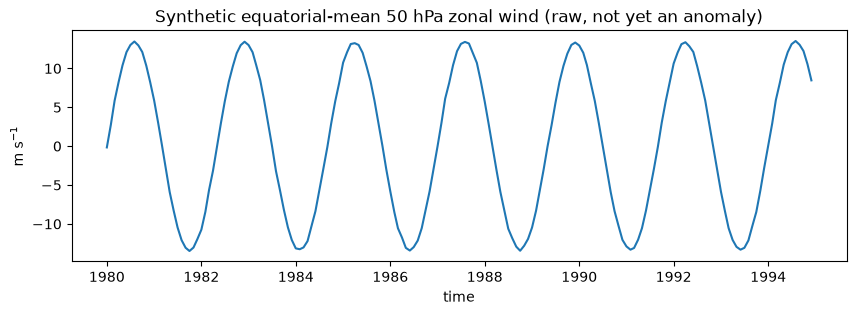

In [4]:
ds_u["u50"].sel(lat=slice(-5, 5)).mean(dim=["lat", "lon"]).plot(figsize=(10, 3))
plt.title("Synthetic equatorial-mean 50 hPa zonal wind (raw, not yet an anomaly)")
plt.ylabel("m s$^{-1}$")
plt.show()

## 2. Compute QBO-MJO metrics with the public API

`compute_qbo_mjo_metrics` is a pure function: it takes the two Datasets above plus a handful of parameters, and returns `(output, diagnostics)` with **no file or plot I/O**. This makes it suitable for notebooks, pipelines, and unit tests -- contrast with `process_qbo_mjo_metrics`/`qbo_mjo_driver.py` (Section 4), which read from files on disk and always write NetCDF/PNG/JSON outputs.

Full parameter documentation: [`pcmdi_metrics.qbo.compute_qbo_mjo_metrics`](https://pcmdi.github.io/pcmdi_metrics/generated/pcmdi_metrics.qbo.compute_qbo_mjo_metrics.html).

In [5]:
from pcmdi_metrics.qbo import compute_qbo_mjo_metrics

output, diagnostics = compute_qbo_mjo_metrics(
    ds_u,
    ds_olr,
    varname="u50",
    varname2="olr",
    start="1980-01",
    end="1994-12",
    taper_to_mean=True,
    model="SyntheticDemo",
    member="r1i1p1",
    debug=False,
)

print(json.dumps(output, indent=2))

2026-07-20 16:57:29,636 [WARNING]: temporal.py(_set_data_var_attrs:997) >> 'time' does not have a calendar encoding attribute set, which is used to determine the `cftime.datetime` object type for the output time coordinates. Defaulting to CF 'standard' calendar. Otherwise, set the calendar type (e.g., ds['time'].encoding['calendar'] = 'noleap') and try again.


2026-07-20 16:57:29,639 [WARNING]: temporal.py(_set_data_var_attrs:997) >> 'time' does not have a calendar encoding attribute set, which is used to determine the `cftime.datetime` object type for the output time coordinates. Defaulting to CF 'standard' calendar. Otherwise, set the calendar type (e.g., ds['time'].encoding['calendar'] = 'noleap') and try again.


2026-07-20 16:57:29,712 [WARNING]: temporal.py(_set_data_var_attrs:997) >> 'time' does not have a calendar encoding attribute set, which is used to determine the `cftime.datetime` object type for the output time coordinates. Defaulting to CF 'standard' calendar. Otherwise, set the calendar type (e.g., ds['time'].encoding['calendar'] = 'noleap') and try again.


end_yr: 1994
end_mo: 12
start_yr_str is  1980
start_mo_str is  01
start_da is  1
end_yr_str is  1994
end_mo_str is  12
end_da is 1
sd of entire qbo index - smoothed u50 anomalies averaged 10s-10n and all lons
8.190154830389789
end_yr: 1994
end_mo: 12
start_yr_str is  1980
start_mo_str is  01
start_da is  1
end_yr_str is  1994
end_mo_str is  12
end_da is 31


mean: [[ 3.71374263e-05  5.47773525e-05  2.94982838e-05  3.74381998e-05
   7.12253168e-05  6.58642748e-05  4.45844053e-05  2.94425845e-05
   4.32977540e-05  4.69738989e-05  3.32329146e-05  2.73343703e-05
   5.21650618e-05  3.88418193e-05  8.27299882e-05  2.50785542e-05
   5.06054857e-05  3.28374481e-05  7.43611818e-05  2.51370384e-05
   7.26177968e-05  4.68207254e-05  9.86153918e-06  2.76824903e-05
   6.21964864e-05  6.45414184e-05  1.02737131e-05  4.30749569e-05
  -3.73184480e-06  6.26365072e-05  8.96199708e-06  3.72543946e-05
   4.66202109e-05  5.19701171e-05  5.66015005e-05  4.93049083e-05]
 [ 3.12416669e-05  4.32504094e-05  9.20707407e-06  8.07749457e-05
   5.26886361e-05  6.36307377e-05  6.96991629e-05  4.26989864e-05
   1.78237360e-06  4.17827359e-05  5.02434414e-05  8.34679959e-05
   2.77966737e-05 -1.06385426e-06  6.91171081e-05  3.10884934e-05
   7.38431845e-05  7.61324191e-05  2.59641711e-05  2.81726425e-05
   8.47407282e-05  3.43385400e-05  1.75563800e-05  1.18889893e-05
   

qbo_phase, qbo_phase_year_list: east [1981, 1983, 1985, 1988, 1990, 1992]
qbo_phase, qbo_phase_year_list: west [1980, 1982, 1984, 1987, 1989, 1991]
metric1 (mjo_activity): 3.8208348492914737
metric2 (mjo_activity_diff): -0.01239866241258805
{
  "SyntheticDemo": {
    "r1i1p1": {
      "mjo_activity": 3.8208348492914737,
      "mjo_activity_diff": -0.01239866241258805,
      "qbo_east_years": [
        1981,
        1983,
        1985,
        1988,
        1990,
        1992
      ],
      "qbo_west_years": [
        1980,
        1982,
        1984,
        1987,
        1989,
        1991
      ]
    }
  }
}


/home/lee1043/git/pcmdi_metrics_20241112/pcmdi_metrics/pcmdi_metrics/qbo/lib/compute_qbo_mjo_metrics.py:342: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  t.year - 1 for t in qbo_phase_ds.indexes["time"].to_datetimeindex()
/home/lee1043/git/pcmdi_metrics_20241112/pcmdi_metrics/pcmdi_metrics/qbo/lib/compute_qbo_mjo_metrics.py:342: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  t.year - 1 for t in qbo_phase_ds.indexes["time"].to_datetimeindex()


`output` is keyed by `model` then `member`, and contains:

* **`mjo_activity`**: DJF standard deviation of Kelvin/MJO-filtered OLR, averaged over the Maritime Continent (50E-170E, 20S-5N) -- the overall MJO activity level.
* **`mjo_activity_diff`**: the same quantity, but composited over QBO-easterly DJF seasons minus QBO-westerly DJF seasons -- the QBO-MJO teleconnection signal. With real data this is typically positive (more MJO activity during QBO-easterly winters); with our synthetic data, which has no such relationship built in, it should come out close to zero.
* **`qbo_east_years`** / **`qbo_west_years`**: the December years classified as QBO-easterly/-westerly DJF seasons, used to build the composites above.

`diagnostics` carries the intermediate xarray objects behind those numbers, so you can inspect or re-plot anything without recomputing:

In [6]:
list(diagnostics.keys())

['std',
 'u_index',
 'u_index_smoothed',
 'u_index_smoothed_djf',
 'olr_region',
 'olr_std_map',
 'olr_std_map_phase',
 'olr_std_map_diff']

## 3. Inspect and plot the diagnostics

`pcmdi_metrics.qbo.lib` also exposes the same plotting helpers `process_qbo_mjo_metrics` uses internally, so you can reuse them directly on the `diagnostics` returned above.

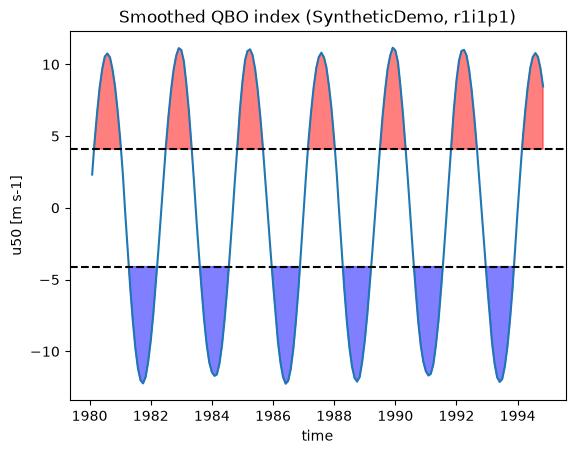

In [7]:
from pcmdi_metrics.qbo.lib import diag_plot, test_plot_time_series

test_plot_time_series(
    diagnostics["u_index_smoothed"]["u50"],
    output_file=None,
    std=diagnostics["std"],
    title="Smoothed QBO index (SyntheticDemo, r1i1p1)",
)

The QBO east/west composite years (shaded above) are exactly `output["SyntheticDemo"]["r1i1p1"]["qbo_east_years"]` / `["qbo_west_years"]`.

The main diagnostic figure -- grey contours of overall DJF MJO-filtered OLR activity, with the QBO east-minus-west difference filled in color over the Maritime Continent box used for `mjo_activity_diff` -- is reproduced with `diag_plot`:

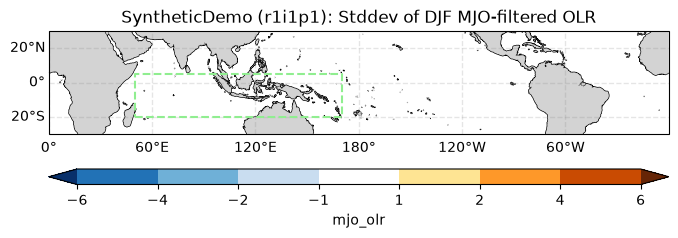

In [8]:
diag_plot(
    diagnostics["olr_std_map"],
    diagnostics["olr_std_map_diff"],
    fig_title="SyntheticDemo (r1i1p1): Stddev of DJF MJO-filtered OLR",
    output_file=None,
    sub_region=(50, 170, -20, 5),
)

## 4. Using real data

For an actual science analysis, use one of the file-path-based entry points instead of fabricating data:

* **`pcmdi_metrics.qbo.process_qbo_mjo_metrics(params)`** -- runs the same computation as above for a single model/member, but starting from NetCDF file paths: it loads (and optionally regrids) the inputs, calls `compute_qbo_mjo_metrics`, and writes the NetCDF/PNG/JSON diagnostic files. This is the function to call directly if you already have a `u50`/`ua` file and an `olr`/`rlut` file in hand.
* **`qbo_mjo_driver.py`** (`pcmdi_metrics/qbo/qbo_mjo_driver.py`) -- a batch driver that searches a model archive (via `xsearch`) for all matching models/members, and calls `process_qbo_mjo_metrics` once per model/member. This is the entry point used for full multi-model QBO-MJO assessments, and is not run from this notebook since it depends on a local ESGF-style data archive.

The parameter dictionary `process_qbo_mjo_metrics` expects looks like this (not executed here, since these example paths are specific to the original development machine):

```python
params = {
    "model": "ERA5",
    "exp": None,
    "member": None,
    "input_file": "/path/to/ERA5_u50_monthly_1979-2021.nc",
    "input_file2": "/path/to/ERA5_olr_daily_40s40n_1979-2021.nc",
    "varname": "u50",
    "level": None,  # hPa; set to e.g. 50 if input_file has a plev dimension
    "varname2": "olr",
    "start": "1979-01",
    "end": "2010-12",
    "regrid": True,
    "regrid_tool": "xesmf",
    "target_grid": "2x2",
    "taper_to_mean": True,
    "output_dir": "./output_data",
    "debug": False,
}

from pcmdi_metrics.qbo import process_qbo_mjo_metrics
output = process_qbo_mjo_metrics(params)
```

Required real inputs are a multi-decade **monthly** zonal wind record at 50 hPa (e.g. ERA5 or a CMIP `ua` file) and a multi-decade **daily** OLR record (e.g. NOAA interpolated OLR or a CMIP `rlut` file); both need to span the same DJF seasons so the QBO phase composites in Section 2/3 have OLR data to composite over.